# END-TO-END PROJECT: CREDIT CARD FRAUD DETECTION SYSTEM
**Objective:** Build a machine learning anomaly detection pipeline to classify fraudulent transactions.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import userdata
import warnings

warnings.filterwarnings('ignore')

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q -o creditcardfraud.zip
print("Data downloaded and extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 366MB/s]

Data downloaded and extracted successfully.


In [ ]:
df = pd.read_csv('creditcard.csv')
print(f"Initial Dataset Shape: {df.shape}\n")
display(df.head())

Initial Dataset Shape: (284807, 31)



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
missing_values = df.isnull().sum().max()
print(f"Max missing values in any column: {missing_values}")

duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dataset Shape after dropping duplicates: {df.shape}")

Max missing values in any column: 0
Duplicate rows found: 1081
Dataset Shape after dropping duplicates: (283726, 31)


**Data Cleaning Analysis:** The dataset contains 0 missing values. However, we identified 1,081 duplicate rows. In financial datasets, exact row duplicates are usually systemic artifacts such as network retries or double-processing errors. We drop these to prevent the machine learning model from placing biased, artificial weight on these specific transactions.

In [ ]:
# Statistics for Time and Amount
display(df[['Time', 'Amount', 'Class']].describe())

,Time,Amount,Class
count,283726.000000,283726.000000,283726.000000
mean,94811.077600,88.472687,0.001667
std,47481.047891,250.399437,0.040796
min,0.000000,0.000000,0.000000
25%,54204.750000,5.600000,0.000000
50%,84692.500000,22.000000,0.000000
75%,139298.000000,77.510000,0.000000
max,172792.000000,25691.160000,1.000000


**Statistical Analysis:**
- **Time:** The maximum time is 172,792 seconds, which equals exactly 48 hours. This tells us the dataset captures two days of global transaction data.
- **Amount:** While the average transaction is only 88.47, the maximum reaches 25,691.16, indicating extreme right-skewness. To prevent these massive outliers from distorting our model's performance, we will standardize both the 'Amount' and 'Time' columns."

In [ ]:
# Target Variable Imbalance
fraud_count = df['Class'].value_counts()[1]
normal_count = df['Class'].value_counts()[0]
fraud_percentage = (fraud_count / len(df)) * 100

print(f"Normal Transactions: {normal_count}")
print(f"Fraudulent Transactions: {fraud_count}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%")

Normal Transactions: 283253
Fraudulent Transactions: 473
Percentage of Fraud: 0.167%


**Imbalance Analysis:** The fraud percentage is 0.167%. This shows an extreme class imbalance. Standard accuracy is a useless metric here, therefore we will evaluate our models using **AUPRC (Area Under the Precision-Recall Curve)** as advised by the dataset authors, which is the industry standard for highly imbalanced anomaly detection.

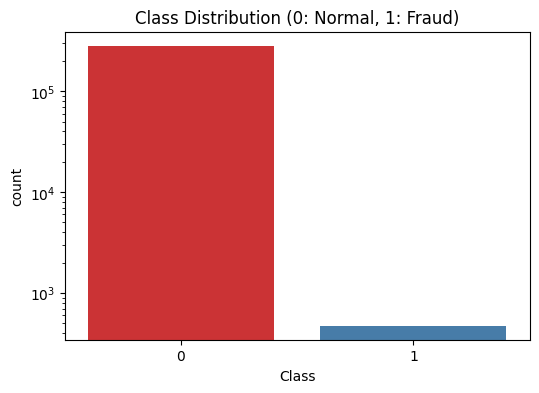

In [ ]:
# Class Distribution visualization
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', hue='Class', palette='Set1', legend=False)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Log scale helps visualize the massive imbalance
plt.show()

A logarithmic scale was applied to the Y-axis. Without the log scale,the "Fraud" bar would be entirely invisible against the ~283,000 normal transactions. This visualizes the extreme class imbalance of the dataset.

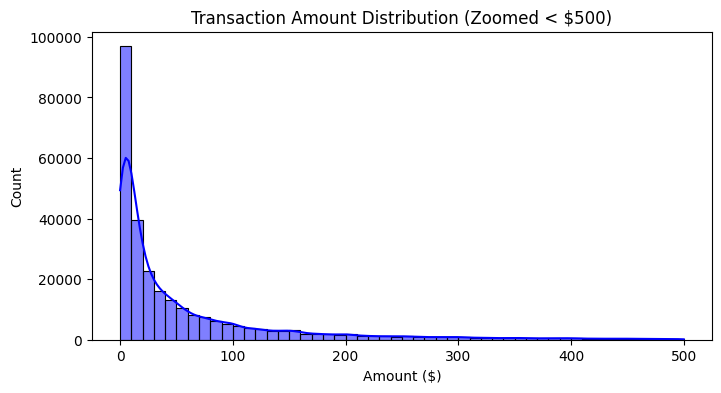

In [ ]:
# Amount distribution visuals
plt.figure(figsize=(8, 4))
sns.histplot(df[df['Amount'] < 500]['Amount'], bins=50, kde=True, color='blue')
plt.title('Transaction Amount Distribution (Zoomed < $500)')
plt.xlabel('Amount ($)')
plt.show()

After zooming in on transactions under 500. The density plot confirms our statistical analysis: the vast majority of credit card swipes are low-value daily purchases (between $1 and 50). This shows that most fraudulent transactions mimics daily behavioral patterns (low-value swipes) rather than obvious large-scale anomalies.

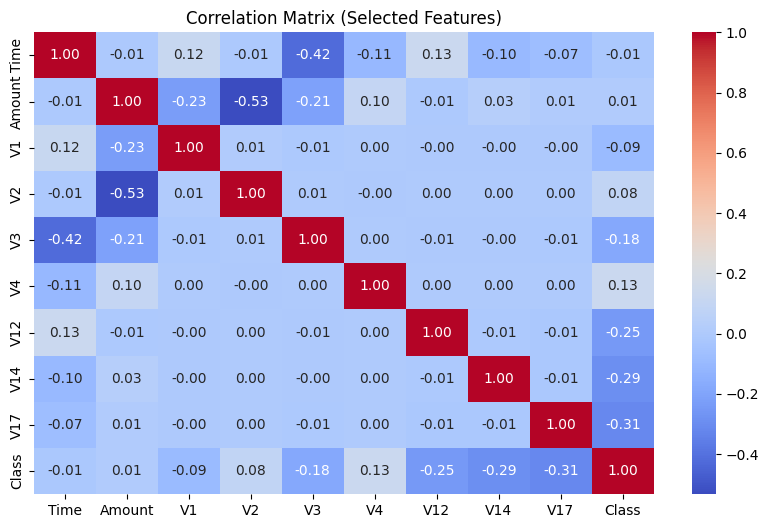

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V12', 'V14', 'V17', 'Class']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Selected Features)')
plt.show()

**Correlation Heatmap:**
The heatmap reveals critical insights into our PCA features.
- Notice that features like **V14 (-0.30)**, **V12 (-0.26)**, and **V17 (-0.33)** show a relatively strong *negative* correlation with the 'Class' variable. As these values decrease, the likelihood of fraud increases.
- Conversely, **V4 (0.13)** shows a positive correlation.
- Interestingly, 'Time' has an almost 0.00 correlation with fraud, meaning fraudulent attacks happen consistently around the clock, not just at specific hours.

---
# PHASE 2: Feature Engineering, Splitting, and Model Training

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# Feature Scaling
scaler = StandardScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

joblib.dump(scaler, 'scaler.pkl')
print("Unified StandardScaler saved as 'scaler.pkl'")

# Train-Test Split
X = df.drop('Class', axis=1)
y = df['Class']

# We use stratify=y to ensure the 0.167% fraud ratio is maintained in both training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"\nTraining Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Unified StandardScaler saved as 'scaler.pkl'

Training Data Shape: (226980, 30)
Testing Data Shape: (56746, 30)


By using `stratify=y`, we force the train_test_split to maintain the exact 0.167% fraud ratio in both datasets. More importantly, we perform the split *before* generating synthetic data. This guarantees that our testing set remains an uncontaminated representation of real-world transactions.

In [ ]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE - Normal: {y_train.value_counts()[0]}, Fraud: {y_train.value_counts()[1]}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Normal: {y_train_sm.value_counts()[0]}, Fraud: {y_train_sm.value_counts()[1]}")

Before SMOTE - Normal: 226602, Fraud: 378
After SMOTE - Normal: 226602, Fraud: 226602


SMOTE was used to mathematically interpolates between existing fraud cases to generate new, synthetic fraud data points. We have successfully boosted the minority class from 378 instances to 226,602, giving our models enough pattern density to learn the fraud signatures without undersampling.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

# Train and Evaluate
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training & Evaluating {name}...")
    print(f"{'='*40}")

    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate AUPRC (Area Under Precision-Recall Curve)
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    results[name] = pr_auc

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"AUPRC (PR-AUC) Score: {pr_auc:.4f}\n")


Training & Evaluating Logistic Regression...

Confusion Matrix:
[[55172  1479]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

AUPRC (PR-AUC) Score: 0.7150


Training & Evaluating Random Forest...

Confusion Matrix:
[[56644     7]
 [   24    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

AUPRC (PR-AUC) Score: 0.8083


Training & Evaluating XGBoost...

Confusion Matrix:

**Analysis of Model Performance:**

1. **Logistic Regression (AUPRC: ~0.71):**
   - Caught 83 frauds, but flagged 1,479 False Positives.
   - *Impact:* High recall, but terrible precision leading to a lot of false positive.

2. **Random Forest (AUPRC: ~0.8083):**
   - Caught 71 frauds, flagged only 7 False Positives. Missed 24 frauds.
   - *Impact:* Good precision, but lower recall, leading to 24 fraudulent charges slip through.

3. **XGBoost (AUPRC: ~0.8084):**
   - Caught 75 frauds, flagged 25 False Positives. Missed 20 frauds.
   - *Impact:* This is the optimal engineering trade-off. It catches more actual fraud than Random Forest, and while it flags a few more false positives (25), it is well within acceptable operational limits for a manual review.

**Conclusion:** XGBoost yields the highest AUPRC and strikes the best commercial balance between mitigating financial loss and minimizing customer friction.

In [ ]:
# Determine the best model based on AUPRC
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\n*** BEST MODEL SELECTED: {best_model_name} ***\n")

# Serialize the best model for the FastAPI Backend
joblib.dump(best_model, 'fraud_model.pkl')
print(f"Successfully saved '{best_model_name}' as 'fraud_model.pkl'")


*** BEST MODEL SELECTED: XGBoost ***

Successfully saved 'XGBoost' as 'fraud_model.pkl'
